In [60]:
import numpy as np
import json
import torch
from pathlib import Path

In [61]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is available!
Number of GPUs: 1
Current GPU Name: NVIDIA GeForce RTX 3060
CUDA Version used by PyTorch: 12.6


Пути к каталогам.

In [62]:
config_dir = Path("./config/")
dataset_dir = Path('./dataset/')

Загрузка файла конфигурации.

In [63]:
config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    configer = json.load(f)

Проверка генерации масок.

In [64]:
from utils.general_functions import generate_masks

masks = generate_masks(masks={}, configer=configer)
print(masks["1zp2lp1rp2lz1rz_001"])

{'zero_poles': 1, 'left_poles': [433, 256], 'right_poles': [140], 'left_zeros': [227, 96], 'right_zeros': [456]}


## Пример работы с dataloader

In [65]:
#SEED = 19
SEED = np.random.randint(0, 10000)
torch.manual_seed(SEED)
np.random.seed(SEED)

In [66]:
from utils.ZerosPolesDataset import ZerosPolesDataset

N_samples = 8
split = configer['split']

# Пути к маскам.
mask_path = Path(dataset_dir) / (split + "_masks.json")
assert mask_path.exists(), f"Mask not found: {mask_path}"
with open(mask_path, "r") as f:
    masks = json.load(f)

# Полный перечень ключей.    
samples_full = list(masks.keys())

# Случайная выборка данных.
samples = np.random.choice(samples_full, size=N_samples, replace=False).tolist()

### Визуализация выбранных данных

In [67]:
from utils.plot_functions import plot_frequency_responses

Конфигуратор стиля графиков.

In [68]:
PLOT_CONFIG = {
    'fontsize': 14,
    'fontsize_legend': 10,
    'fig_width': 14,
    'fig_height_per_row': 4,
    'max_samples_to_plot': 12,
    'markersize_data': 3,
    'markersize_mask': 10,
    'grid_alpha': 0.5,
    'plots': [
        {
            'ylabel': 'Magnitude, dB',
            'xlabel': 'Frequency, Hz',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'mag_db'
        },
        {
            'ylabel': 'Gain (Real)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'real'
        },
        {
            'ylabel': 'Phase, deg',
            'xlabel': 'Frequency, Hz',
            'xscale': 'log',
            'arg_key': 'freq',
            'data_key': 'ph_deg'
        },
        {
            'ylabel': 'Gain (Imag)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'imag'
        }
    ],
    'masks': [
        {'label': 'left_pole',  'color': '#e377c2', 'marker': 'o'},
        {'label': 'right_pole', 'color': '#d62728', 'marker': 'p'},
        {'label': 'left_zero',  'color': '#bcbd22', 'marker': 's'},
        {'label': 'right_zero', 'color': '#ff7f0e', 'marker': '^'},
    ]
}

#### Нет аугментаций

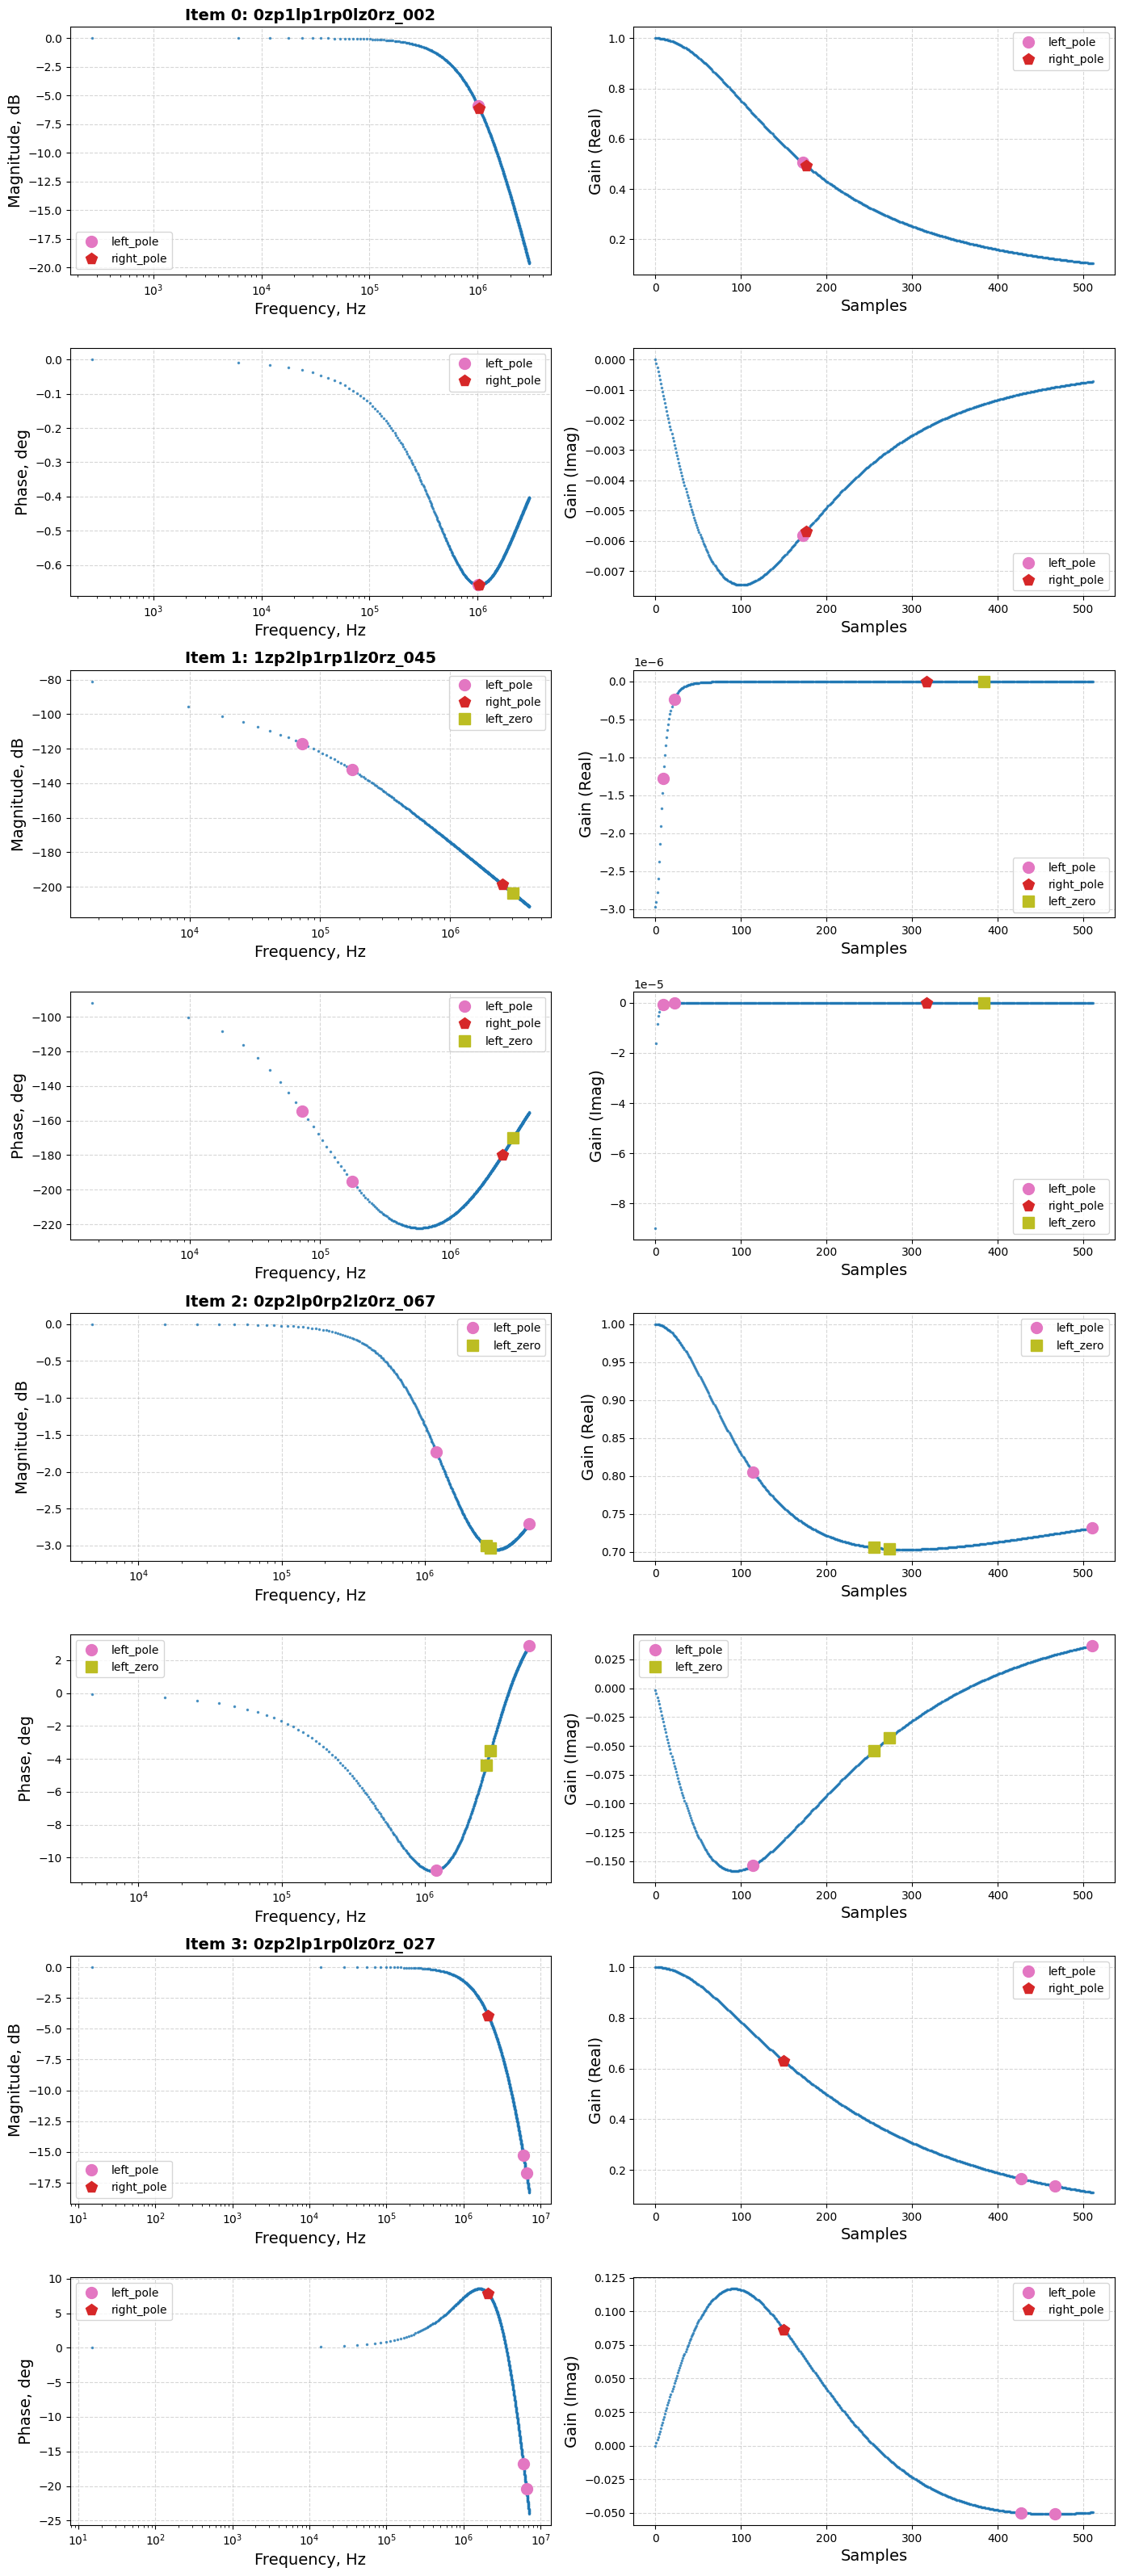

In [69]:
dataset = ZerosPolesDataset(
    dataset_dir = dataset_dir,
    split = configer['split'],
    samples=samples,
    transforms_flag=False
)

plot_frequency_responses(
    dataset_to_plot=dataset,
    samples_list=samples,
    N_plot_samples=4,
    plot_config=PLOT_CONFIG,
    save_path=Path('./readme_img/dataset_samples.png'))

### Визуализация выбранных данных: аугментации

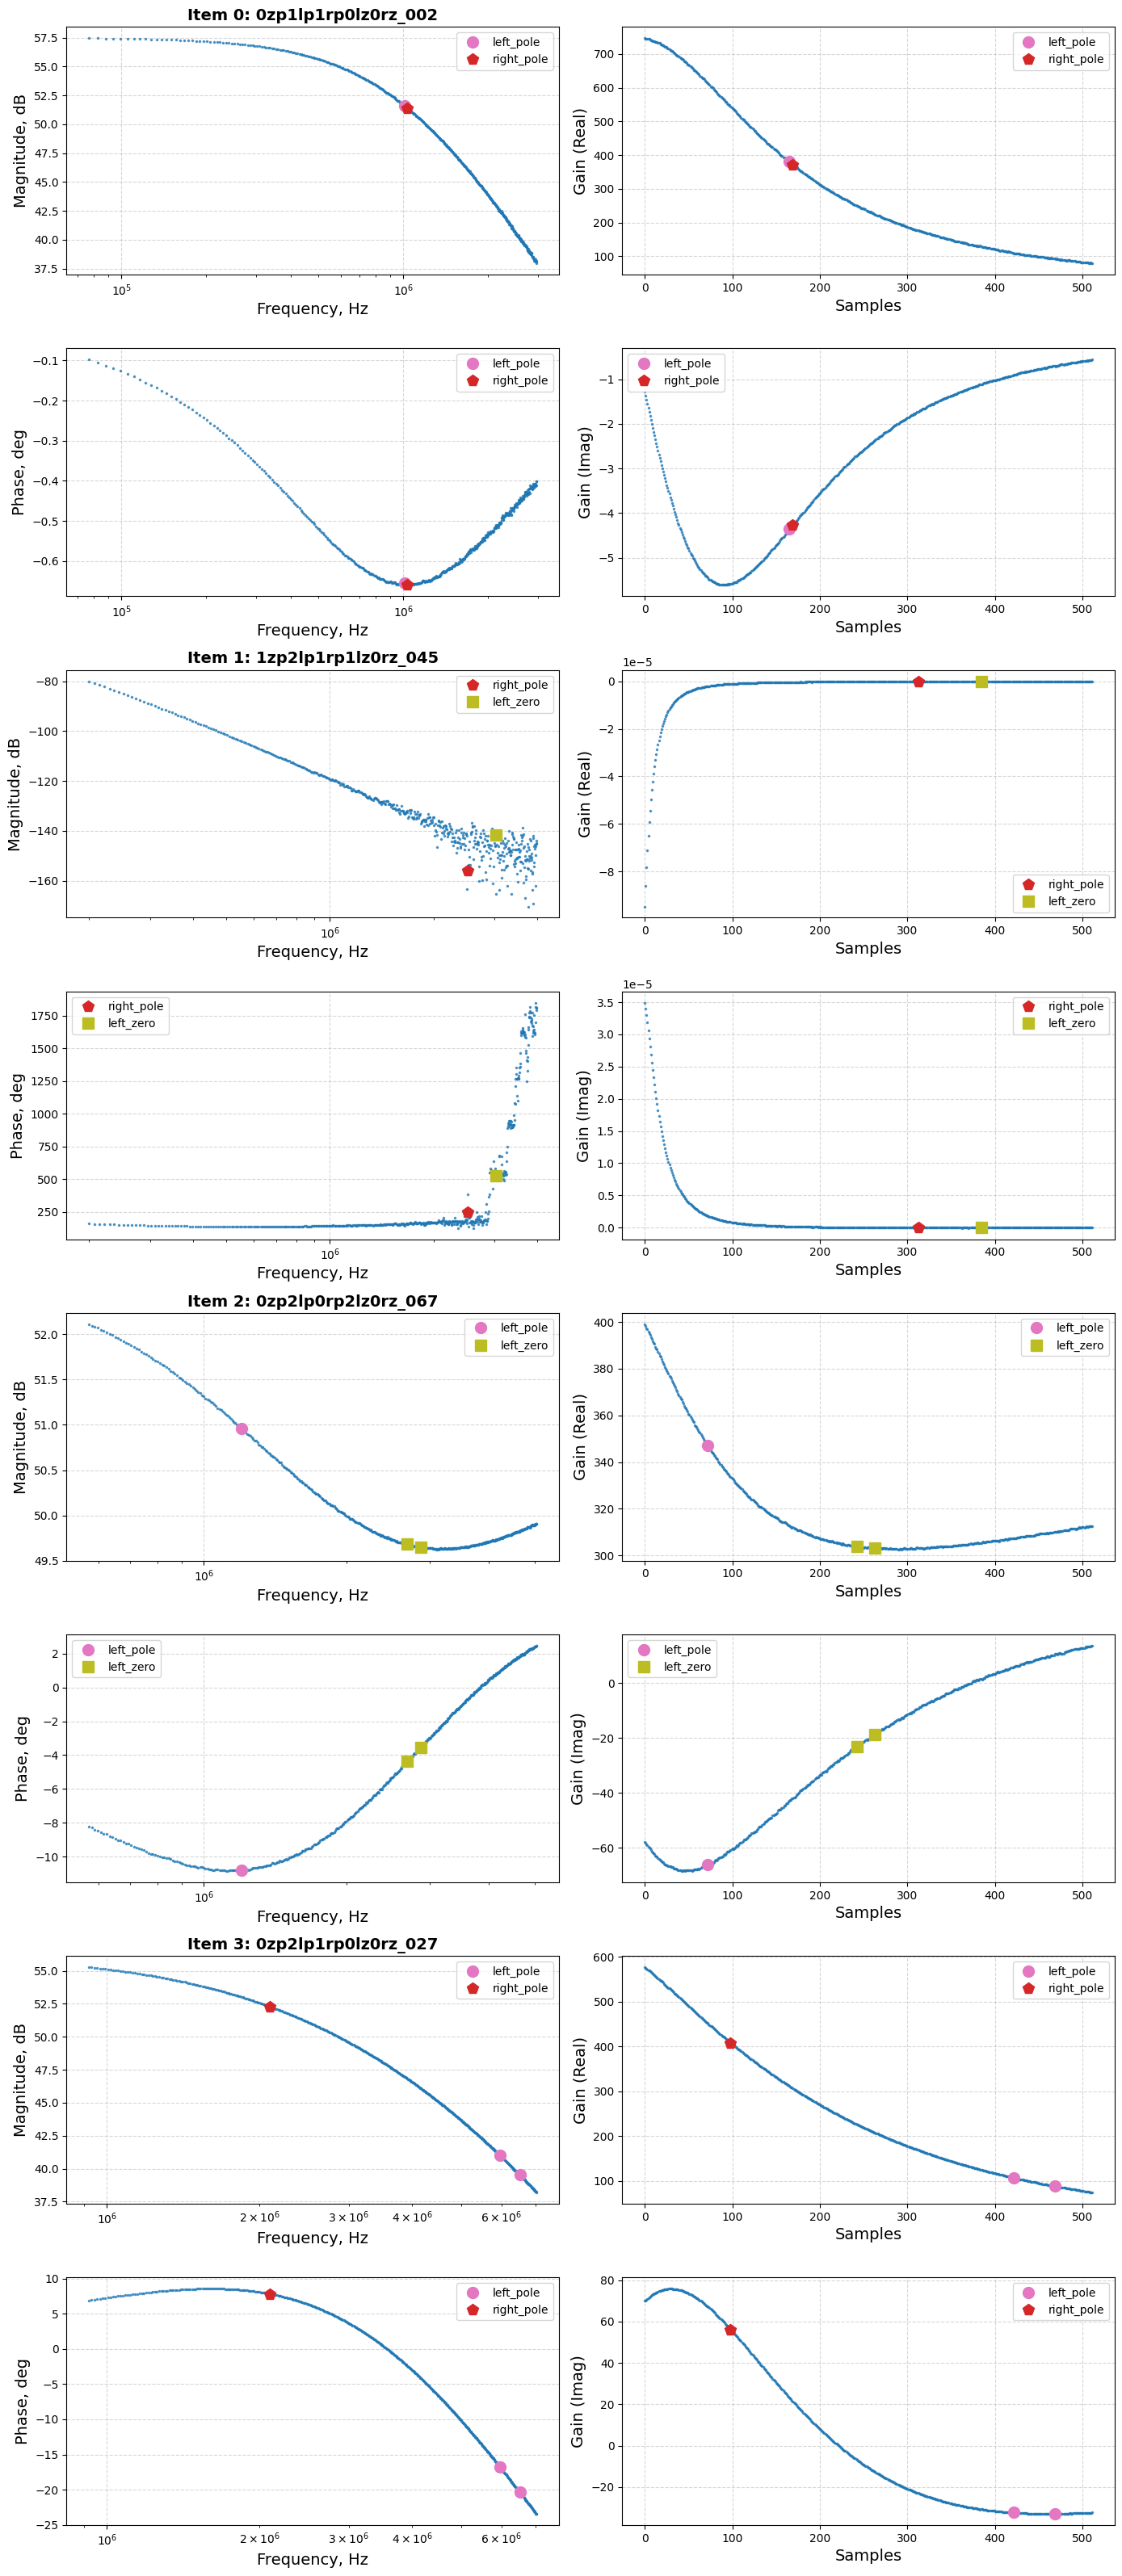

In [70]:
dataset = ZerosPolesDataset(
    dataset_dir = dataset_dir,
    split = configer['split'],
    samples=samples,
    transforms_flag=True,
    crop_size=[0.0, 0.2],
    noise_level=[1e-3, 10e-3],
    noise_alfa=0.6,
    gain=[1e-3, 1e3]
)

plot_frequency_responses(
    dataset_to_plot=dataset,
    samples_list=samples,
    N_plot_samples=4,
    plot_config=PLOT_CONFIG)